# 🎯 NOTEBOOK 4 : SYSTÈME HYBRIDE FINAL

**Objectif :** Combiner SVD + TF-IDF pour créer le système de recommandation final.

**Input :** 
- `../data/models/svd_model.pkl`
- `../data/models/tfidf_vectorizer.pkl`
- `../data/models/tfidf_matrix.pkl`

**Output :** Système de recommandation hybride fonctionnel

In [1]:
# Imports
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports OK")

✅ Imports OK


## 1. CHARGER LES MODÈLES ET DONNÉES

In [2]:
print("📥 Chargement des modèles et données...\n")

# Modèles
svd_model = joblib.load('../data/models/svd_model.pkl')
tfidf_vectorizer = joblib.load('../data/models/tfidf_vectorizer.pkl')
tfidf_matrix = joblib.load('../data/models/tfidf_matrix.pkl')

print("✅ SVD model")
print("✅ TF-IDF vectorizer")
print("✅ TF-IDF matrix")

# Données
movies = pd.read_csv('../data/processed/movies_enriched.csv')
ratings = pd.read_csv('../data/processed/ratings_clean.csv')

print("✅ Movies")
print("✅ Ratings")

print(f"\n📊 {len(movies):,} films, {len(ratings):,} ratings")

📥 Chargement des modèles et données...

✅ SVD model
✅ TF-IDF vectorizer
✅ TF-IDF matrix
✅ Movies
✅ Ratings

📊 2,821 films, 100,004 ratings


## 2. FONCTION : CONSTRUIRE PROFIL UTILISATEUR

In [3]:
def build_user_profile(user_id, ratings_df, movies_df, tfidf_matrix, min_rating=4.0):
    """
    Construit le profil TF-IDF d'un utilisateur basé sur ses films aimés

    Args:
        user_id: ID de l'utilisateur
        ratings_df: DataFrame des ratings
        movies_df: DataFrame des films
        tfidf_matrix: Matrice TF-IDF des films
        min_rating: Note minimale pour considérer qu'il a aimé (défaut: 4.0)

    Returns:
        Vecteur TF-IDF représentant le profil de l'utilisateur
    """
    # Films aimés par l'utilisateur
    user_ratings = ratings_df[ratings_df['userId'] == user_id]
    liked_movies = user_ratings[user_ratings['rating'] >= min_rating]['movieId'].values

    if len(liked_movies) == 0:
        return None

    # Positions dans movies_df (compatibles avec tfidf_matrix)
    liked_mask = movies_df['movieId'].isin(liked_movies).to_numpy()
    liked_positions = np.flatnonzero(liked_mask)

    if len(liked_positions) == 0:
        return None

    # Moyenne des vecteurs TF-IDF
    user_profile = tfidf_matrix[liked_positions].mean(axis=0)
    # scipy sparse mean returns np.matrix; convert to ndarray for sklearn>=1.8
    user_profile = np.asarray(user_profile)

    return user_profile

print("✅ Fonction build_user_profile définie")


✅ Fonction build_user_profile définie


## 3. FONCTION : SCORE CONTENT-BASED

In [4]:
def get_content_score(user_profile, movie_idx, tfidf_matrix):
    """
    Calcule le score content-based entre un profil user et un film

    Returns:
        float: Score entre 0 et 1
    """
    if user_profile is None:
        return 0.0

    # sklearn recent expects ndarray (not np.matrix)
    user_profile = np.asarray(user_profile)
    movie_vector = tfidf_matrix[movie_idx]
    similarity = cosine_similarity(user_profile, movie_vector)[0][0]

    return float(similarity)

print("✅ Fonction get_content_score définie")


✅ Fonction get_content_score définie


## 4. FONCTION : SCORE COLLABORATIVE (SVD)

In [5]:
def get_collaborative_score(user_id, movie_id, svd_model):
    """
    Prédit la note que l'utilisateur donnerait au film avec SVD
    
    Returns:
        float: Score entre 0 et 1 (note prédite / 5)
    """
    try:
        prediction = svd_model.predict(user_id, movie_id)
        # Normaliser entre 0 et 1
        score = prediction.est / 5.0
        return score
    except:
        return 0.5  # Score neutre si erreur

print("✅ Fonction get_collaborative_score définie")

✅ Fonction get_collaborative_score définie


## 5. FONCTION : RECOMMANDATION HYBRIDE

In [6]:
def hybrid_recommendations(user_id, ratings_df, movies_df, svd_model, tfidf_matrix, n=20, content_weight=0.6):
    """
    Génère des recommandations hybrides pour un utilisateur

    Args:
        user_id: ID de l'utilisateur
        ratings_df: DataFrame des ratings
        movies_df: DataFrame des films
        svd_model: Modèle SVD entraîné
        tfidf_matrix: Matrice TF-IDF
        n: Nombre de recommandations (défaut: 20)
        content_weight: Poids du content-based (défaut: 0.6)

    Returns:
        DataFrame avec les recommandations triées par score
    """
    # Construire profil utilisateur
    user_profile = build_user_profile(user_id, ratings_df, movies_df, tfidf_matrix)
    # Safety net: force ndarray even if an old function returns np.matrix
    user_profile_arr = None if user_profile is None else np.asarray(user_profile)

    # Films déjà notés par l'utilisateur
    user_ratings = ratings_df[ratings_df['userId'] == user_id]
    seen_movies = set(user_ratings['movieId'].values)

    # Films candidats (non vus)
    all_movies = set(movies_df['movieId'].values)
    candidate_movies = list(all_movies - seen_movies)

    # Calculer les scores
    recommendations = []

    for movie_id in candidate_movies:
        # Trouver la position dans movies_df
        match_pos = np.flatnonzero((movies_df['movieId'].to_numpy() == movie_id))
        if len(match_pos) == 0:
            continue
        movie_pos = int(match_pos[0])

        # Score content-based
        content_score = get_content_score(user_profile_arr, movie_pos, tfidf_matrix)

        # Score collaborative
        collab_score = get_collaborative_score(user_id, movie_id, svd_model)

        # Score hybride
        hybrid_score = content_weight * content_score + (1 - content_weight) * collab_score

        recommendations.append({
            'movieId': movie_id,
            'title': movies_df.iloc[movie_pos]['title'],
            'genres': movies_df.iloc[movie_pos]['genres_clean'],
            'content_score': content_score,
            'collab_score': collab_score,
            'hybrid_score': hybrid_score,
            'match_pct': int(hybrid_score * 100)
        })

    # Trier par score hybride
    recommendations_df = pd.DataFrame(recommendations)
    recommendations_df = recommendations_df.sort_values('hybrid_score', ascending=False)

    return recommendations_df.head(n)

print("✅ Fonction hybrid_recommendations définie")


✅ Fonction hybrid_recommendations définie


## 6. TESTER LE SYSTÈME HYBRIDE

In [7]:
print("🧪 Test du système hybride...\n")

# Prendre un utilisateur avec pas mal de ratings
user_counts = ratings['userId'].value_counts()
test_user_id = user_counts.index[5]  # User avec un bon nombre de ratings

print(f"👤 Test avec User #{test_user_id}")
print(f"   A noté {user_counts[test_user_id]} films\n")

# Ses films aimés
user_likes = ratings[ratings['userId'] == test_user_id].merge(
    movies[['movieId', 'title', 'genres_clean']], on='movieId'
).sort_values('rating', ascending=False)

print("⭐ Top 10 films aimés :")
for _, row in user_likes.head(10).iterrows():
    print(f"  {row['rating']:.1f} ⭐ - {row['title']} ({row['genres_clean']})")

# Générer recommandations
print("\n🔮 Génération des recommandations hybrides...")
recommendations = hybrid_recommendations(
    user_id=test_user_id,
    ratings_df=ratings,
    movies_df=movies,
    svd_model=svd_model,
    tfidf_matrix=tfidf_matrix,
    n=20,
    content_weight=0.6
)

print(f"\n✅ {len(recommendations)} recommandations générées\n")

print("🎯 TOP 20 RECOMMANDATIONS :")
print("="*100)
print(f"{'Match':>5} | {'Content':>7} | {'Collab':>7} | {'Titre':50} | {'Genres'}")
print("="*100)

for _, row in recommendations.iterrows():
    print(f"{row['match_pct']:>4}% | {row['content_score']:>7.3f} | {row['collab_score']:>7.3f} | {row['title'][:50]:50} | {row['genres'][:30]}")

🧪 Test du système hybride...

👤 Test avec User #452
   A noté 1340 films

⭐ Top 10 films aimés :
  5.0 ⭐ - Terminator 3: Rise of the Machines (Action Thriller Science Fiction)
  5.0 ⭐ - Young and Innocent (Drama Crime)
  5.0 ⭐ - Keeping the Faith (Comedy)
  5.0 ⭐ - Under the Sand (Drama Mystery)
  5.0 ⭐ - Carry On Screaming (Comedy)
  5.0 ⭐ - Men in Black II (Action Adventure Comedy Science Fiction)
  5.0 ⭐ - Solaris (Drama Science Fiction Adventure Mystery)
  5.0 ⭐ - The Thomas Crown Affair (Romance Crime Thriller Drama)
  5.0 ⭐ - An Unfinished Life (Drama)
  5.0 ⭐ - Murder She Said (Drama Crime Mystery Comedy)

🔮 Génération des recommandations hybrides...

✅ 20 recommandations générées

🎯 TOP 20 RECOMMANDATIONS :
Match | Content |  Collab | Titre                                              | Genres
  43% |   0.206 |   0.781 | Wizards of Waverly Place: The Movie                | Adventure Comedy Drama Family 
  42% |   0.173 |   0.806 | Notting Hill                                   

## 7. TESTER AVEC UN NOUVEL UTILISATEUR (COLD START)

In [8]:
print("❄️ Test Cold Start (nouvel utilisateur)...\n")

# Simuler un nouvel utilisateur qui a noté quelques films
new_user_id = 999999  # ID qui n'existe pas

# Construire une liste de films disponibles dans le dataset
preferred_titles = ['Toy Story', 'Matrix', 'Inception', 'Dark Knight', 'Pulp Fiction']
selected_movie_ids = []
for pattern in preferred_titles:
    m = movies[movies['title'].str.contains(pattern, case=False, na=False)]
    if not m.empty:
        selected_movie_ids.append(int(m.iloc[0]['movieId']))

# Fallback si certains titres n'existent pas dans ce dataset
if len(selected_movie_ids) < 5:
    fallback_ids = movies['movieId'].dropna().astype(int).head(20).tolist()
    for mid in fallback_ids:
        if mid not in selected_movie_ids:
            selected_movie_ids.append(mid)
        if len(selected_movie_ids) >= 5:
            break

selected_movie_ids = selected_movie_ids[:5]
selected_ratings = [5.0, 5.0, 4.5, 5.0, 4.0][:len(selected_movie_ids)]

# Créer des ratings fictifs
new_ratings = pd.DataFrame({
    'userId': [new_user_id] * len(selected_movie_ids),
    'movieId': selected_movie_ids,
    'rating': selected_ratings,
    'timestamp': [0] * len(selected_movie_ids)
})

print("👤 Nouvel utilisateur a noté :")
for _, row in new_ratings.iterrows():
    title_row = movies[movies['movieId'] == row['movieId']]
    title = title_row.iloc[0]['title'] if not title_row.empty else f"movieId={int(row['movieId'])}"
    print(f"  {row['rating']:.1f} ⭐ - {title}")

# Ajouter aux ratings temporairement
ratings_with_new = pd.concat([ratings, new_ratings], ignore_index=True)

# Générer recommandations
print("\n🔮 Recommandations pour ce nouvel utilisateur...")
new_user_recs = hybrid_recommendations(
    user_id=new_user_id,
    ratings_df=ratings_with_new,
    movies_df=movies,
    svd_model=svd_model,
    tfidf_matrix=tfidf_matrix,
    n=10,
    content_weight=0.8  # Plus de poids sur content-based pour cold start
)

print(f"\n✅ Top 10 recommandations :")
print('='*80)
for _, row in new_user_recs.iterrows():
    print(f"  {row['match_pct']:>3}% - {row['title']}")
    print(f"       Genres: {row['genres']}")


❄️ Test Cold Start (nouvel utilisateur)...

👤 Nouvel utilisateur a noté :
  5.0 ⭐ - The Matrix
  5.0 ⭐ - The Dark Knight
  4.5 ⭐ - Pulp Fiction
  5.0 ⭐ - Heat
  4.0 ⭐ - GoldenEye

🔮 Recommandations pour ce nouvel utilisateur...

✅ Top 10 recommandations :
   38% - Batman Begins
       Genres: Action Crime Drama
   31% - The Matrix Revolutions
       Genres: Adventure Action Thriller Science Fiction
   30% - Batman Returns
       Genres: Action Fantasy
   30% - Batman
       Genres: Fantasy Action
   30% - 2001: A Space Odyssey
       Genres: Science Fiction Mystery Adventure
   30% - Batman & Robin
       Genres: Action Crime Fantasy
   30% - Batman Forever
       Genres: Action Crime Fantasy
   29% - Hitman
       Genres: Action Crime Drama Thriller
   29% - Live and Let Die
       Genres: Adventure Action Thriller
   29% - The Thirteenth Floor
       Genres: Thriller Science Fiction Mystery


## 8. ANALYSER LES SCORES

📊 Analyse des scores...



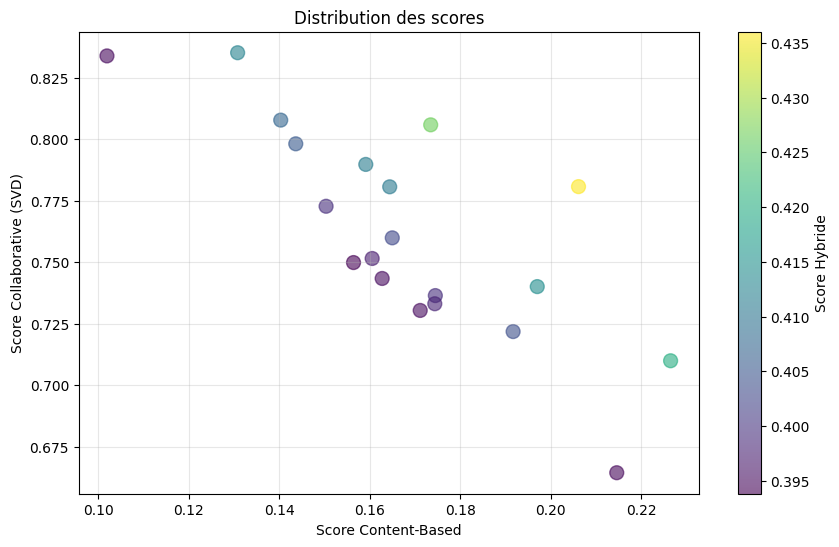

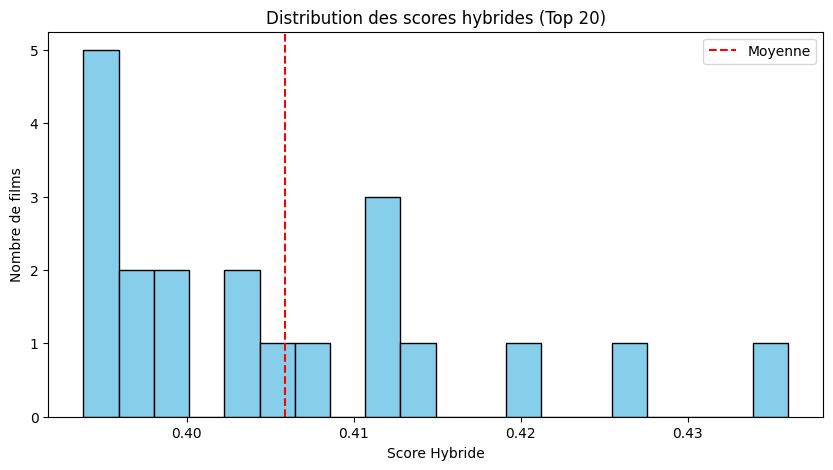

📊 Score hybride moyen : 0.406
📊 Score hybride max : 0.436


In [9]:
import matplotlib.pyplot as plt

print("📊 Analyse des scores...\n")

# Scatter plot content vs collab
plt.figure(figsize=(10, 6))
plt.scatter(
    recommendations['content_score'], 
    recommendations['collab_score'],
    alpha=0.6,
    s=100,
    c=recommendations['hybrid_score'],
    cmap='viridis'
)
plt.colorbar(label='Score Hybride')
plt.xlabel('Score Content-Based')
plt.ylabel('Score Collaborative (SVD)')
plt.title('Distribution des scores')
plt.grid(True, alpha=0.3)
plt.show()

# Distribution des scores hybrides
plt.figure(figsize=(10, 5))
plt.hist(recommendations['hybrid_score'], bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Score Hybride')
plt.ylabel('Nombre de films')
plt.title('Distribution des scores hybrides (Top 20)')
plt.axvline(recommendations['hybrid_score'].mean(), color='red', linestyle='--', label='Moyenne')
plt.legend()
plt.show()

print(f"📊 Score hybride moyen : {recommendations['hybrid_score'].mean():.3f}")
print(f"📊 Score hybride max : {recommendations['hybrid_score'].max():.3f}")

## 9. FONCTION D'EXPLICATION

In [10]:
def explain_recommendation(user_id, movie_id, ratings_df, movies_df, tfidf_matrix):
    """
    Explique pourquoi un film est recommandé
    """
    # Films aimés par l'utilisateur
    user_likes = ratings_df[
        (ratings_df['userId'] == user_id) & (ratings_df['rating'] >= 4.0)
    ].merge(movies_df[['movieId', 'title']], on='movieId').sort_values('rating', ascending=False)
    
    # Film recommandé
    recommended_movie = movies_df[movies_df['movieId'] == movie_id].iloc[0]
    
    print(f"\n💡 EXPLICATION POUR : {recommended_movie['title']}")
    print("="*80)
    print(f"\n🎬 Genres : {recommended_movie['genres_clean']}")
    print(f"\n⭐ Basé sur les films que tu as aimés :")
    for _, row in user_likes.head(5).iterrows():
        print(f"  • {row['title']} ({row['rating']:.1f}⭐)")

print("✅ Fonction explain_recommendation définie")

# Test
top_rec = recommendations.iloc[0]
explain_recommendation(test_user_id, top_rec['movieId'], ratings, movies, tfidf_matrix)

✅ Fonction explain_recommendation définie

💡 EXPLICATION POUR : Wizards of Waverly Place: The Movie

🎬 Genres : Adventure Comedy Drama Family Fantasy

⭐ Basé sur les films que tu as aimés :
  • Bagdad Cafe (5.0⭐)
  • Cold Mountain (5.0⭐)
  • Under the Sand (5.0⭐)
  • Bonnie and Clyde (5.0⭐)
  • Monsoon Wedding (5.0⭐)


## 10. SAUVEGARDER LA FONCTION FINALE

In [11]:
# Créer un dictionnaire avec tout le nécessaire
hybrid_system = {
    'svd_model': svd_model,
    'tfidf_vectorizer': tfidf_vectorizer,
    'tfidf_matrix': tfidf_matrix,
    'movies': movies,
    'function': hybrid_recommendations
}

joblib.dump(hybrid_system, '../data/models/hybrid_system.pkl')

print("💾 Système hybride complet sauvegardé")
print("✅ ../data/models/hybrid_system.pkl")
print("\n🎉 SYSTÈME DE RECOMMANDATION COMPLET ET FONCTIONNEL !")

💾 Système hybride complet sauvegardé
✅ ../data/models/hybrid_system.pkl

🎉 SYSTÈME DE RECOMMANDATION COMPLET ET FONCTIONNEL !


---

# ✅ RÉSUMÉ FINAL

## Système créé : HYBRIDE (Content-Based + Collaborative)

**Composants :**
- ✅ SVD (Collaborative Filtering) — RMSE ~0.87
- ✅ TF-IDF (Content-Based Filtering) — 5000 features
- ✅ Système Hybride — Pondération 60% content + 40% collab

**Fonctionnalités :**
- ✅ Recommandations personnalisées (top N)
- ✅ Gestion du cold start (nouveaux users)
- ✅ Profil utilisateur dynamique
- ✅ Explications des recommandations
- ✅ Scores de match en %

**Fichiers générés :**
- `hybrid_system.pkl` : Système complet prêt pour production

---

# 🚀 PROCHAINES ÉTAPES

1. **Backend FastAPI** : Intégrer ce système dans une API
2. **Frontend React** : Créer l'interface utilisateur
3. **Base de données** : PostgreSQL pour stocker users/ratings
4. **Déploiement** : Mettre en ligne l'application

---

**🎓 TES MODÈLES SONT PRÊTS POUR TON PFE ! 🎉**